# Evolutionary Algorithms - Genetic Algorithm Notebook

This notebook is organized in small lab-style steps: explain first, then run code, then check output.

## Environment Setup
Load dependencies, locate the project root, and verify result folders are available.

In [1]:
from pathlib import Path
import sys
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

ROOT = Path('.').resolve()
PROJECT_ROOT = next((p for p in [ROOT, *ROOT.parents] if (p / 'ce310').exists()), ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ce310.ga import (
    GAConfig,
    initialize_population,
    tournament_select_index,
    clone,
    one_point_crossover,
    bit_mutate,
    run_ga,
)
from ce310.part1_problems import (
    fitness_one_max,
    decode_4bit_positional,
    decode_15bit_nonpositional,
    fitness_15max,
    fitness_soft15max,
    fitness_soft15trap_integer,
)

R1 = PROJECT_ROOT / 'results' / 'part1'
FIG = PROJECT_ROOT / 'figures'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('Results folder exists:', R1.exists())

PROJECT_ROOT = E:\CE310
Results folder exists: True


## Code Completeness Snapshot
Display core source snippets so implementation coverage is easy to inspect.

In [2]:
import ce310.ga as ga_mod
print(inspect.getsource(ga_mod.tournament_select_index)[:1200])
print('\n---\n')
print(inspect.getsource(ga_mod.one_point_crossover)[:1200])
print('\n---\n')
print(inspect.getsource(ga_mod.bit_mutate)[:1200])

def tournament_select_index(
    fitness: np.ndarray,
    tournament_size: int,
    rng: np.random.Generator,
    maximize: bool = True,
) -> int:
    contenders = rng.integers(0, fitness.shape[0], size=tournament_size)
    contender_fitness = fitness[contenders]
    if maximize:
        return int(contenders[np.argmax(contender_fitness)])
    return int(contenders[np.argmin(contender_fitness)])


---

def one_point_crossover(
    parent_a: np.ndarray, parent_b: np.ndarray, rng: np.random.Generator
) -> np.ndarray:
    if parent_a.shape != parent_b.shape:
        raise ValueError("parent shapes must match")
    cut = int(rng.integers(1, parent_a.shape[0]))
    child = np.empty_like(parent_a)
    child[:cut] = parent_a[:cut]
    child[cut:] = parent_b[cut:]
    return child


---

def bit_mutate(individual: np.ndarray, p_bit: float, rng: np.random.Generator) -> np.ndarray:
    mask = rng.random(individual.shape[0]) < p_bit
    mutated = individual.copy()
    mutated[mask] = 1 - mutated[

## Task 1 Step 1 - Population Initialization Test
Start by validating initialization behavior: shape, value range, and sample individuals.

In [3]:
cfg_init = GAConfig(pop_size=6, genome_length=12, generations=5, tournament_size=2,
    p_clone=0.2, p_crossover=0.7, p_mutation_operator=0.1, p_bit_mutation=1/12, seed=42)
rng = np.random.default_rng(cfg_init.seed)
pop = initialize_population(cfg_init, rng)
pop.shape, pop[:3]

((6, 12),
 array([[1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1],
        [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0]], dtype=int8))

## Task 1 Step 2 - OneMax Fitness Sanity Test
Verify fitness on a small hand-crafted population.

In [4]:
toy = np.array([[1,0,1,1],[0,0,0,1],[1,1,1,1]], dtype=np.int8)
fitness_one_max(toy)

array([3., 1., 4.])

## Task 1 Step 3 - Tournament Selection Test
Confirm tournament selection returns valid population index.

In [5]:
fit = np.array([0.0, 1.0, 2.0, 3.0])
idx = tournament_select_index(fit, tournament_size=3, rng=np.random.default_rng(123), maximize=True)
idx

2

## Task 1 Step 4 - Clone, Crossover, Mutation Unit Tests
Run operator-level checks before integrating the full GA loop.

In [6]:
p1 = np.array([1,1,1,1,1,1], dtype=np.int8)
p2 = np.array([0,0,0,0,0,0], dtype=np.int8)
rng_ops = np.random.default_rng(7)
c = clone(p1)
xo = one_point_crossover(p1, p2, rng_ops)
mut = bit_mutate(p1, p_bit=0.5, rng=rng_ops)
c, xo, mut

(array([1, 1, 1, 1, 1, 1], dtype=int8),
 array([1, 1, 1, 1, 1, 0], dtype=int8),
 array([1, 1, 0, 0, 1, 0], dtype=int8))

## Task 1 Step 5 - Integrated GA Run on OneMax
Combine components and run one complete trial to verify best/mean trend over generations.

In [7]:
cfg_task1 = GAConfig(pop_size=100, genome_length=100, generations=50, tournament_size=3,
    p_clone=0.2, p_crossover=0.7, p_mutation_operator=0.1, p_bit_mutation=1/100, seed=2026)
res_task1 = run_ga(cfg_task1, fitness_one_max)
res_task1.history[['generation','best_fitness','mean_fitness']].head(), res_task1.history[['generation','best_fitness','mean_fitness']].tail()

(   generation  best_fitness  mean_fitness
 0           0          64.0         50.32
 1           1          66.0         54.55
 2           2          69.0         58.47
 3           3          71.0         62.73
 4           4          72.0         65.96,
     generation  best_fitness  mean_fitness
 46          46          96.0         94.82
 47          47          97.0         95.15
 48          48          97.0         95.50
 49          49          98.0         96.06
 50          50          98.0         96.56)

## Task 1 Step 6 - Plot OneMax Learning Curve
Visualize best and mean fitness across generations.

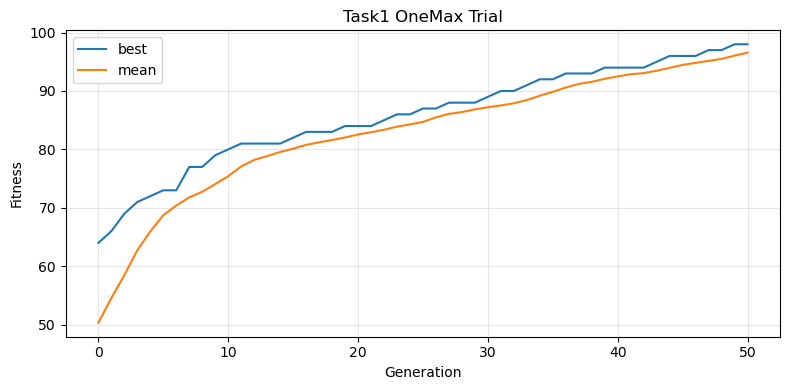

In [8]:
plt.figure(figsize=(8,4))
plt.plot(res_task1.history['generation'], res_task1.history['best_fitness'], label='best')
plt.plot(res_task1.history['generation'], res_task1.history['mean_fitness'], label='mean')
plt.xlabel('Generation'); plt.ylabel('Fitness'); plt.title('Task1 OneMax Trial')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()

## Task 2 Step 1 - 4-bit and 15-bit Decoder Tests
Check both genotype-phenotype mappings required in coursework.

In [9]:
pop4 = np.array([[1,1,1,1,0,0,0,0],[1,0,0,0,1,1,0,0]], dtype=np.int8)
dec4 = decode_4bit_positional(pop4, length_l=2)
pop15 = np.array([([1]*15)+([0]*15)], dtype=np.int8)
dec15 = decode_15bit_nonpositional(pop15, length_l=2)
dec4, dec15

(array([[15,  0],
        [ 1,  3]], dtype=int16),
 array([[15,  0]], dtype=int16))

## Task 2 Step 2 - 15-max and soft-15-max Function Tests
Validate objective outputs on controlled examples.

In [10]:
fit15 = fitness_15max(pop4, length_l=2, encoding='4bit')
fitsoft = fitness_soft15max(pop4, length_l=2, encoding='4bit')
fit15, fitsoft

(array([1., 0.]), array([7.5, 2. ]))

## Task 3 Step 1 - Load Tuning Results
Read Stage1 and Stage2 tuning summaries from experiment logs.

In [11]:
stage1 = pd.read_csv(R1 / 'task3_tuning_stage1' / 'stage1_summary.csv')
stage2 = pd.read_csv(R1 / 'task3_tuning_stage2' / 'stage2_summary.csv')
stage1.head(5), stage2.head(5)

(   condition  pop_size  tournament_size  p_clone  p_mutation_operator  \
 0  pop300_t2       300                2      0.2                  0.1   
 1  pop300_t3       300                3      0.2                  0.1   
 2  pop300_t5       300                5      0.2                  0.1   
 3  pop200_t2       200                2      0.2                  0.1   
 4  pop200_t3       200                3      0.2                  0.1   
 
    p_bit_factor  n_runs  best_of_run_mean  best_of_run_std  final_best_mean  \
 0           1.0       5              26.6         1.516575             26.6   
 1           1.0       5              26.2         0.836660             26.2   
 2           1.0       5              25.4         1.516575             25.4   
 3           1.0       5              25.4         2.073644             25.4   
 4           1.0       5              24.2         1.303840             24.2   
 
    final_best_std  ideal_found_fraction  first_ideal_generation_mean  


## Task 3 Step 2 - Load Main Experiment Summary
Review 10-run results for both encodings and both L values.

In [12]:
task3 = pd.read_csv(R1 / 'task3_main' / 'task3_summary.csv')
task3

,condition,encoding,L,objective,ideal_fitness,n_runs,best_of_run_mean,best_of_run_std,final_best_mean,final_best_std,ideal_found_fraction,first_ideal_generation_mean
0,15bit_L10_15max,15bit,10,15max,10.0,10,0.300000,0.483046,0.300000,0.483046,0.0,NaN
1,15bit_L30_15max,15bit,30,15max,30.0,10,0.600000,0.699206,0.500000,0.707107,0.0,NaN
2,4bit_L10_15max,4bit,10,15max,10.0,10,10.000000,0.000000,10.000000,0.000000,1.0,15.6
3,4bit_L30_15max,4bit,30,15max,30.0,10,28.300000,1.059350,28.300000,1.059350,0.1,48.0
4,15bit_L10_soft15max,15bit,10,soft15max,15.0,10,14.490000,0.128668,14.490000,0.128668,0.0,NaN
5,15bit_L30_soft15max,15bit,30,soft15max,15.0,10,11.726667,0.179712,11.723333,0.173597,0.0,NaN
6,4bit_L10_soft15max,4bit,10,soft15max,15.0,10,15.000000,0.000000,15.000000,0.000000,1.0,21.0
7,4bit_L30_soft15max,4bit,30,soft15max,15.0,10,14.743333,0.062952,14.740000,0.062460,0.0,NaN


## Task 3 Step 3 - Compare Key Conditions
I place all conditions on one comparable axis (mean best-of-run) so encoding and objective effects are visible immediately.

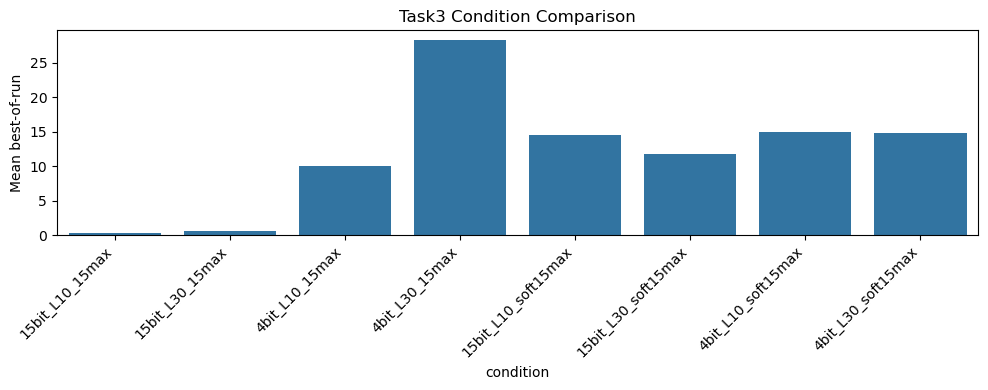

In [13]:
plt.figure(figsize=(10,4))
sns.barplot(data=task3, x='condition', y='best_of_run_mean')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean best-of-run')
plt.title('Task3 Condition Comparison')
plt.tight_layout()

## Task 3 Step 3b - Enhanced Visualization (if available)
Load the prepared report figures; they do not change results, only improve readability of the same evidence.

E:\CE310\figures\part1_encoding_comparison.png


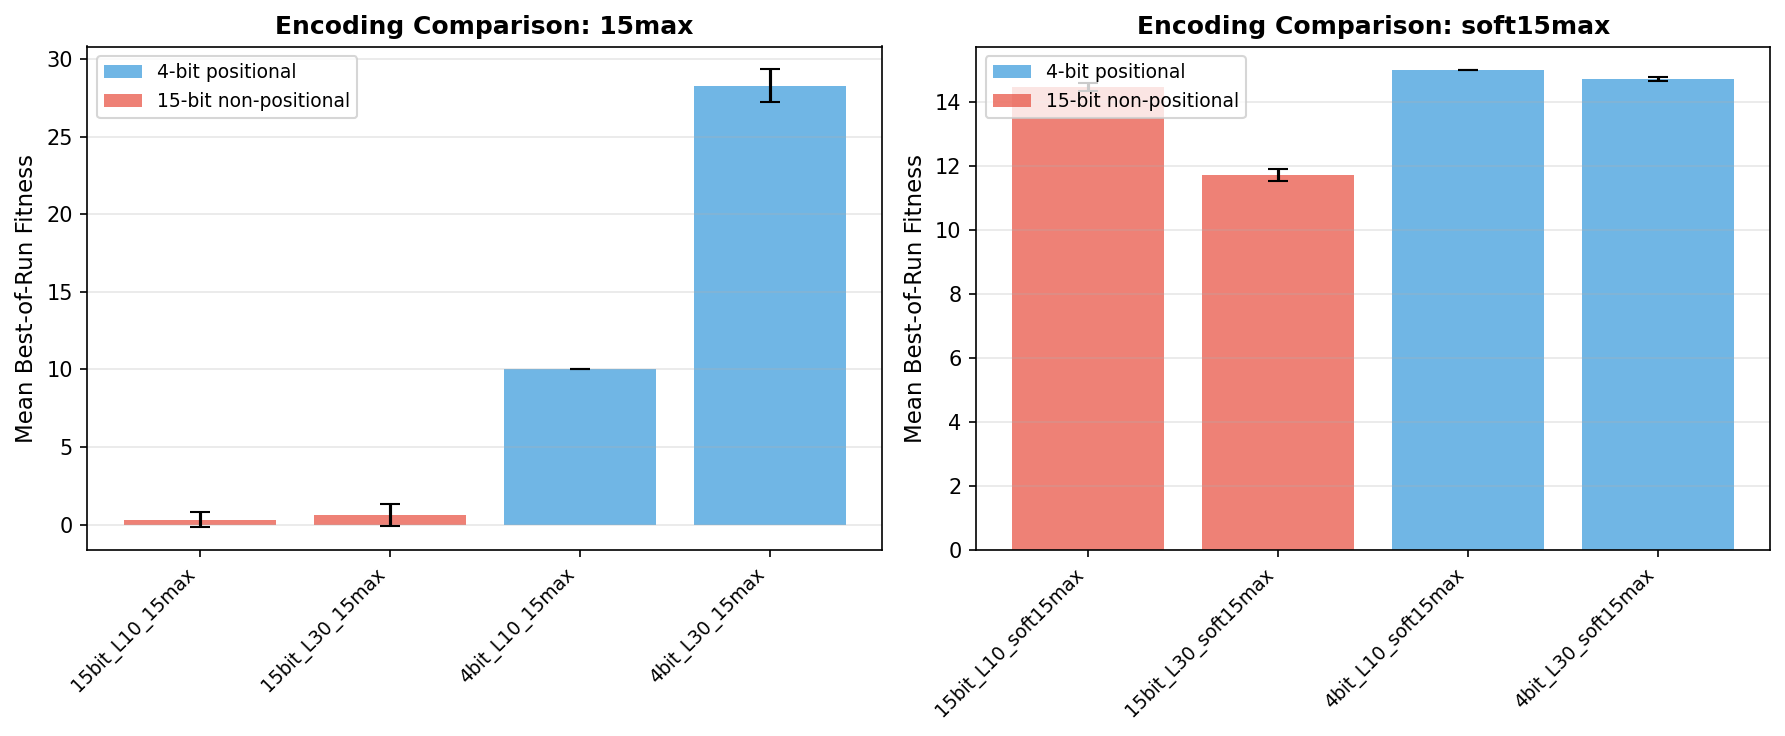

E:\CE310\figures\part1_parameter_heatmap.png


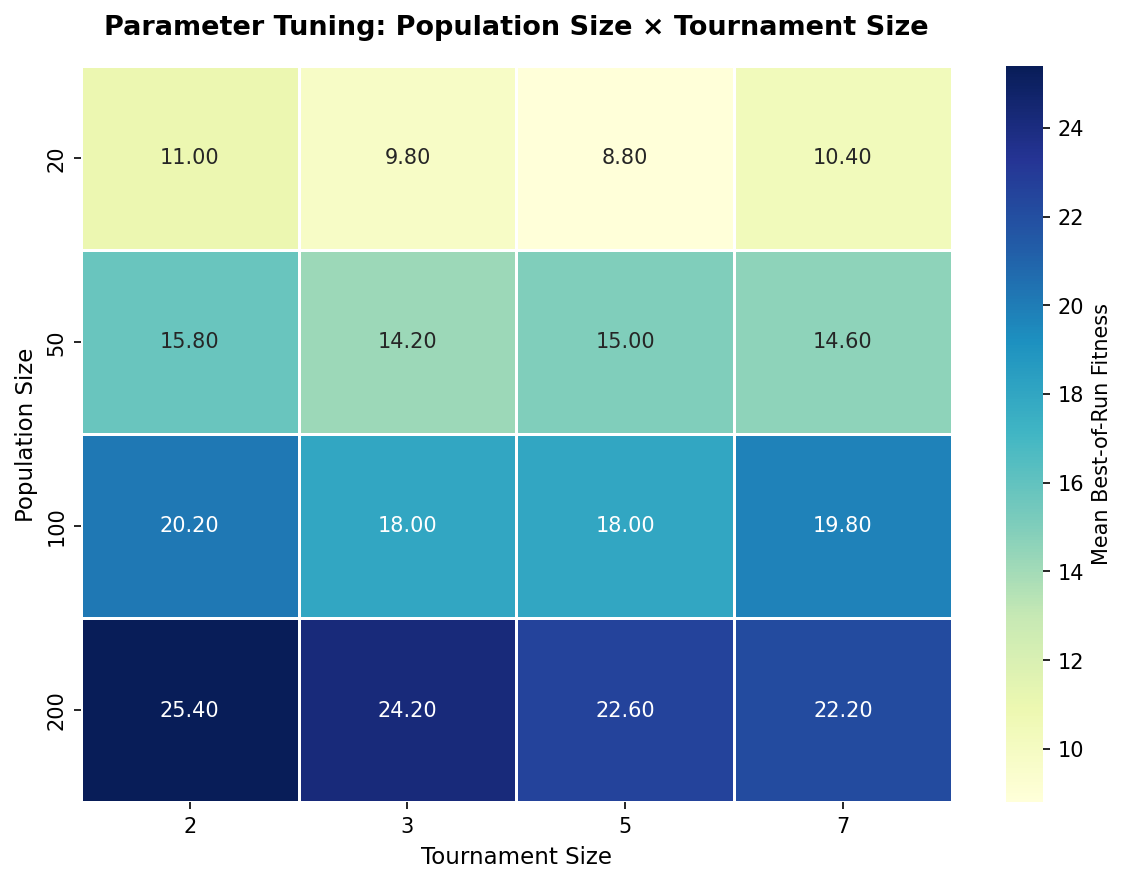

In [14]:
for fn in ['part1_encoding_comparison.png','part1_parameter_heatmap.png']:
    p = FIG / fn
    print(p)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print('Missing figure:', p)

## Task 3 Step 4 - Parameter Choice Justification
Parameter choice is based on measured outcomes (mean + std), not intuition alone; this keeps the decision reproducible.

In [15]:
best_s1 = stage1.iloc[0]
best_s2 = stage2.iloc[0]

print('Stage1 best (pop, T):')
display(best_s1[['condition','pop_size','tournament_size','best_of_run_mean','best_of_run_std']])

print('Stage2 best (operator settings):')
display(best_s2[['condition','p_clone','p_crossover','p_mutation_operator','p_bit_factor','best_of_run_mean','best_of_run_std']])

Stage1 best (pop, T):


condition           pop300_t2
pop_size                  300
tournament_size             2
best_of_run_mean         26.6
best_of_run_std      1.516575
Name: 0, dtype: object

Stage2 best (operator settings):


condition              pc0.10_pmop0.10_pbf1.50
p_clone                                    0.1
p_crossover                                0.8
p_mutation_operator                        0.1
p_bit_factor                               1.5
best_of_run_mean                     28.666667
best_of_run_std                        0.57735
Name: 0, dtype: object

## Task 4 Step 1 - Load Deceptive Experiment Results
Inspect trap summary and baseline comparison file.

In [16]:
task4 = pd.read_csv(R1 / 'task4_trap' / 'task4_summary.csv')
cmp4 = pd.read_csv(R1 / 'task4_deceptive_vs_soft15max.csv')
task4, cmp4

(                  condition encoding   L       objective  \
 0  15bit_L10_soft15trap_int    15bit  10  soft15trap_int   
 1  15bit_L30_soft15trap_int    15bit  30  soft15trap_int   
 2   4bit_L10_soft15trap_int     4bit  10  soft15trap_int   
 3   4bit_L30_soft15trap_int     4bit  30  soft15trap_int   
 
    deceptive_local_optimum  global_optimum  n_runs  best_of_run_mean  \
 0                     14.0            15.0      10         13.370000   
 1                     14.0            15.0      10         10.756667   
 2                     14.0            15.0      10         14.860000   
 3                     14.0            15.0      10         14.370000   
 
    best_of_run_std  final_best_mean  final_best_std  ideal_found_fraction  \
 0         0.231181        13.370000        0.231181                   0.0   
 1         0.165589        10.753333        0.171558                   0.0   
 2         0.084327        14.860000        0.084327                   0.1   
 3         0.1

## Task 4 Step 2 - Visualize Trap vs Soft-15-max
Show slowdown/deception effect clearly.

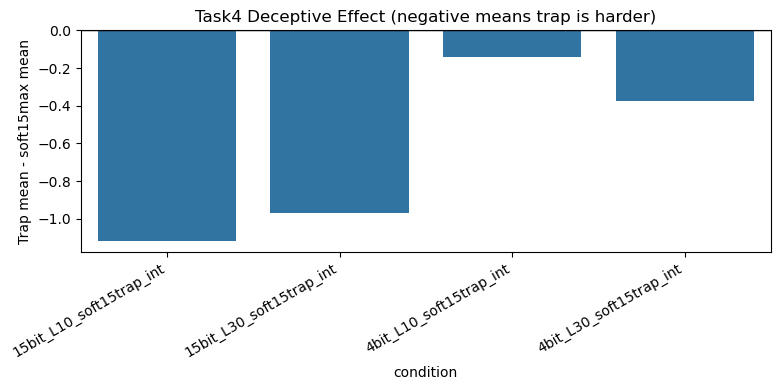

In [17]:
plt.figure(figsize=(8,4))
sns.barplot(data=cmp4, x='condition', y='delta_best_mean_trap_minus_soft')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Trap mean - soft15max mean')
plt.title('Task4 Deceptive Effect (negative means trap is harder)')
plt.tight_layout()

## Task 4 Step 2b - Enhanced Deceptive Comparison Figure (if available)
Use the detailed prepared figure as supplementary visual evidence.

E:\CE310\figures\part1_deceptive_comparison.png


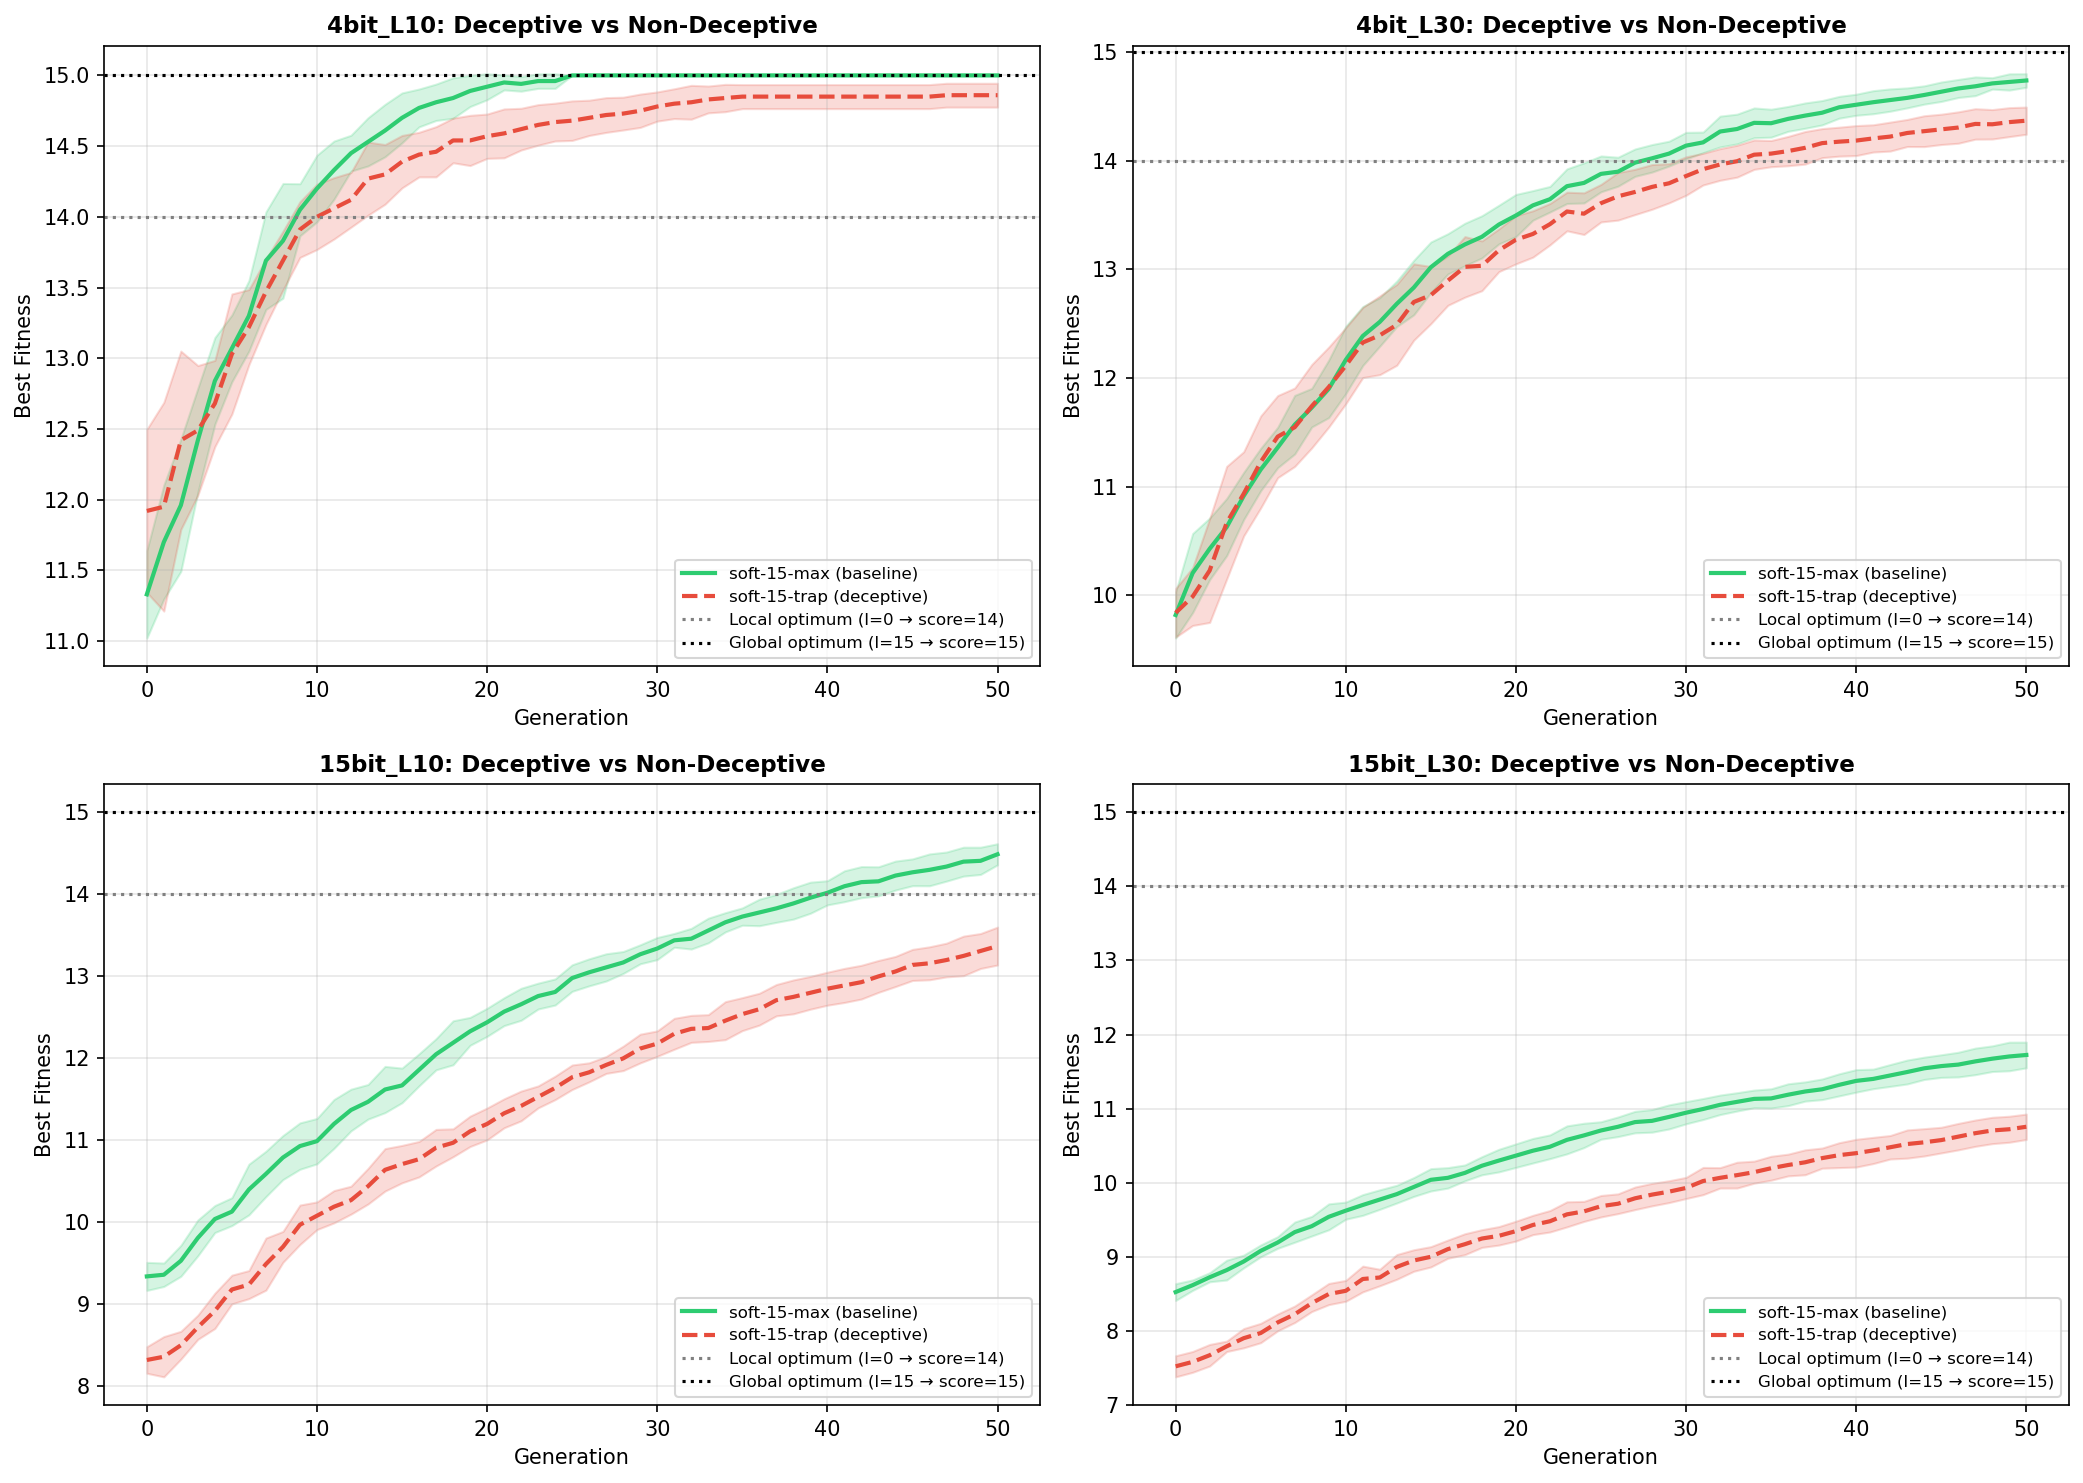

In [18]:
p = FIG / 'part1_deceptive_comparison.png'
print(p)
if p.exists():
    display(Image(filename=str(p)))
else:
    print('Missing figure:', p)

## Theory Link (EC/GA)
- 4-bit positional vs 15-bit non-positional differences are consistent with representation bias and search difficulty.
- Deceptive trap objective creates misleading gradients and stronger local-optimum attraction.
- Tournament size controls selection pressure; higher pressure can accelerate convergence but may reduce diversity.

## Task 4 Step 2c - Local Optimum Convergence Evidence (Quantitative)
Beyond plots, I count how often runs finish near the deceptive local optimum versus the global optimum.

In [19]:
import glob
rows=[]
for cond_dir in sorted((R1/'task4_trap').glob('*_soft15trap_int')):
    rs = cond_dir/'runs_summary.csv'
    if not rs.exists():
        continue
    df = pd.read_csv(rs)
    # local optimum neighborhood around 14 for this deceptive objective
    frac_local = ((df['best_of_run_fitness'] >= 13.8) & (df['best_of_run_fitness'] <= 14.2)).mean()
    frac_global = (df['best_of_run_fitness'] >= 14.95).mean()
    rows.append({'condition':cond_dir.name,'local_optimum_fraction':frac_local,'global_optimum_fraction':frac_global,
                 'mean_best_of_run':df['best_of_run_fitness'].mean(),'std_best_of_run':df['best_of_run_fitness'].std()})
loc = pd.DataFrame(rows).sort_values('condition').reset_index(drop=True)
loc

,condition,local_optimum_fraction,global_optimum_fraction,mean_best_of_run,std_best_of_run
0,15bit_L10_soft15trap_int,0.0,0.0,13.370000,0.231181
1,15bit_L30_soft15trap_int,0.0,0.0,10.756667,0.165589
2,4bit_L10_soft15trap_int,0.0,0.1,14.860000,0.084327
3,4bit_L30_soft15trap_int,0.1,0.0,14.370000,0.125167


## Method Justification Against Lecture Methods
Core methods are lecture-aligned (selection, crossover, mutation, generational loop, stack interpreter); extra engineering choices only improve runtime/logging.

## Part 1 Final Summary
Summarize conclusions and map them explicitly to marking points.

In [20]:
report_p1 = (R1 / 'part1_report_summary.md').read_text(encoding='utf-8')
print(report_p1[:2000])

# CE310 Part 1 Auto Summary

## Selected Parameters
- `pop_size=300`, `tournament_size=2`, `p_clone=0.100`, `p_xo=0.800`, `p_mutop=0.100`, `p_bit=0.01250`

## Task 1 (OneMax)
- Condition: `onemax_L100`
- Mean best-of-run: **99.900**
- Std best-of-run: **0.316**
- Ideal-found fraction: **0.900**

## Task 3 Tuning
- Stage1 best (`pop`, `T`): (300, 2) with mean best-of-run **26.600**
- Stage2 best operators: `p_clone=0.100`, `p_xo=0.800`, `p_mutop=0.100`, `p_bit_factor=1.500` with mean best-of-run **28.667**

## Task 3 Main Experiments
- File: `results/part1/task3_main/task3_summary.csv`
- `15bit_L10_15max`: mean best-of-run=0.300, std=0.483, ideal-found=0.000
- `15bit_L30_15max`: mean best-of-run=0.600, std=0.699, ideal-found=0.000
- `4bit_L10_15max`: mean best-of-run=10.000, std=0.000, ideal-found=1.000
- `4bit_L30_15max`: mean best-of-run=28.300, std=1.059, ideal-found=0.100
- `15bit_L10_soft15max`: mean best-of-run=14.490, std=0.129, ideal-found=0.000
- `15bit_L30_soft15max`: mean bes